In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("school_dropout_dataset_final_10000.csv")
df.sample(10)

,Student_ID,Age,Gender,Overall_Performance_Percentage,Homework_Completion,Family_Income,Distance_to_School_km,Health_Issues,Bullying_Experience,Teacher_Feedback,Fees_Status,Sibling_Count,Dropout_Status
3738,S03739,11,Female,62,77,Low,9.4,No,No,Average,Overdue (3+ Months),2,Not Dropout
2569,S02570,11,Male,33,57,High,13.2,No,Yes,Average,Paid,1,Not Dropout
7076,S07077,13,Female,50,61,Low,9.9,No,Yes,Poor,Paid,3,Not Dropout
3298,S03299,14,Male,87,73,High,4.9,No,Yes,Average,Paid,2,Not Dropout
2597,S02598,13,Male,67,68,Low,5.8,No,No,Average,Overdue (3+ Months),2,Not Dropout
2691,S02692,12,Female,57,49,High,15.3,No,Yes,Average,Unpaid,1,Not Dropout
3624,S03625,18,Female,39,94,Medium,15.9,No,Yes,Good,Paid,4,Not Dropout
8901,S08902,16,Male,66,27,High,16.0,Yes,No,Good,Paid,0,Not Dropout
8124,S08125,15,Male,49,79,High,6.1,No,No,Poor,Paid,0,Not Dropout
6275,S06276,16,Male,47,79,Low,1.8,Yes,Yes,Poor,Overdue (3+ Months),3,Dropout


In [3]:
df=df.drop(columns=['Teacher_Feedback','Bullying_Experience'])

In [4]:
df['Fees_Status'].value_counts()

Fees_Status
Paid                   6560
Unpaid                 1972
Overdue (3+ Months)    1468
Name: count, dtype: int64

In [5]:
df['Fees_Status'].value_counts()

Fees_Status
Paid                   6560
Unpaid                 1972
Overdue (3+ Months)    1468
Name: count, dtype: int64

In [6]:
df['Sibling_Count'].value_counts()

Sibling_Count
2    1713
3    1688
0    1687
1    1670
4    1653
5    1589
Name: count, dtype: int64

In [7]:
def dropout(x):
    if x == 'Dropout':
        return 1
    else:
        return 0

df['Dropout_Status'] = df['Dropout_Status'].apply(dropout)


In [8]:
df['Dropout_Status'].value_counts()

Dropout_Status
0    7180
1    2820
Name: count, dtype: int64

In [9]:
df.shape

(10000, 11)

In [10]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Fees_Status'] = le.fit_transform(df['Fees_Status'])
df['Health_Issues'] = le.fit_transform(df['Health_Issues'])
df['Family_Income'] = le.fit_transform(df['Family_Income'])

In [11]:
df.columns

Index(['Student_ID', 'Age', 'Gender', 'Overall_Performance_Percentage',
       'Homework_Completion', 'Family_Income', 'Distance_to_School_km',
       'Health_Issues', 'Fees_Status', 'Sibling_Count', 'Dropout_Status'],
      dtype='object')

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Student_ID                      10000 non-null  object 
 1   Age                             10000 non-null  int64  
 2   Gender                          10000 non-null  object 
 3   Overall_Performance_Percentage  10000 non-null  int64  
 4   Homework_Completion             10000 non-null  int64  
 5   Family_Income                   10000 non-null  int64  
 6   Distance_to_School_km           10000 non-null  float64
 7   Health_Issues                   10000 non-null  int64  
 8   Fees_Status                     10000 non-null  int64  
 9   Sibling_Count                   10000 non-null  int64  
 10  Dropout_Status                  10000 non-null  int64  
dtypes: float64(1), int64(8), object(2)
memory usage: 859.5+ KB


In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.describe()

,Age,Overall_Performance_Percentage,Homework_Completion,Family_Income,Distance_to_School_km,Health_Issues,Fees_Status,Sibling_Count,Dropout_Status
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,14.513600,64.005600,60.214100,0.997000,10.244890,0.496900,1.050400,2.471700,0.282000
std,2.277528,19.975046,23.426048,0.820523,5.640649,0.500015,0.584375,1.696964,0.449996
min,11.000000,30.000000,20.000000,0.000000,0.500000,0.000000,0.000000,0.000000,0.000000
25%,13.000000,47.000000,40.000000,0.000000,5.400000,0.000000,1.000000,1.000000,0.000000
50%,15.000000,64.000000,60.000000,1.000000,10.300000,0.000000,1.000000,2.000000,0.000000
75%,17.000000,82.000000,80.000000,2.000000,15.100000,1.000000,1.000000,4.000000,1.000000
max,18.000000,98.000000,100.000000,2.000000,20.000000,1.000000,2.000000,5.000000,1.000000


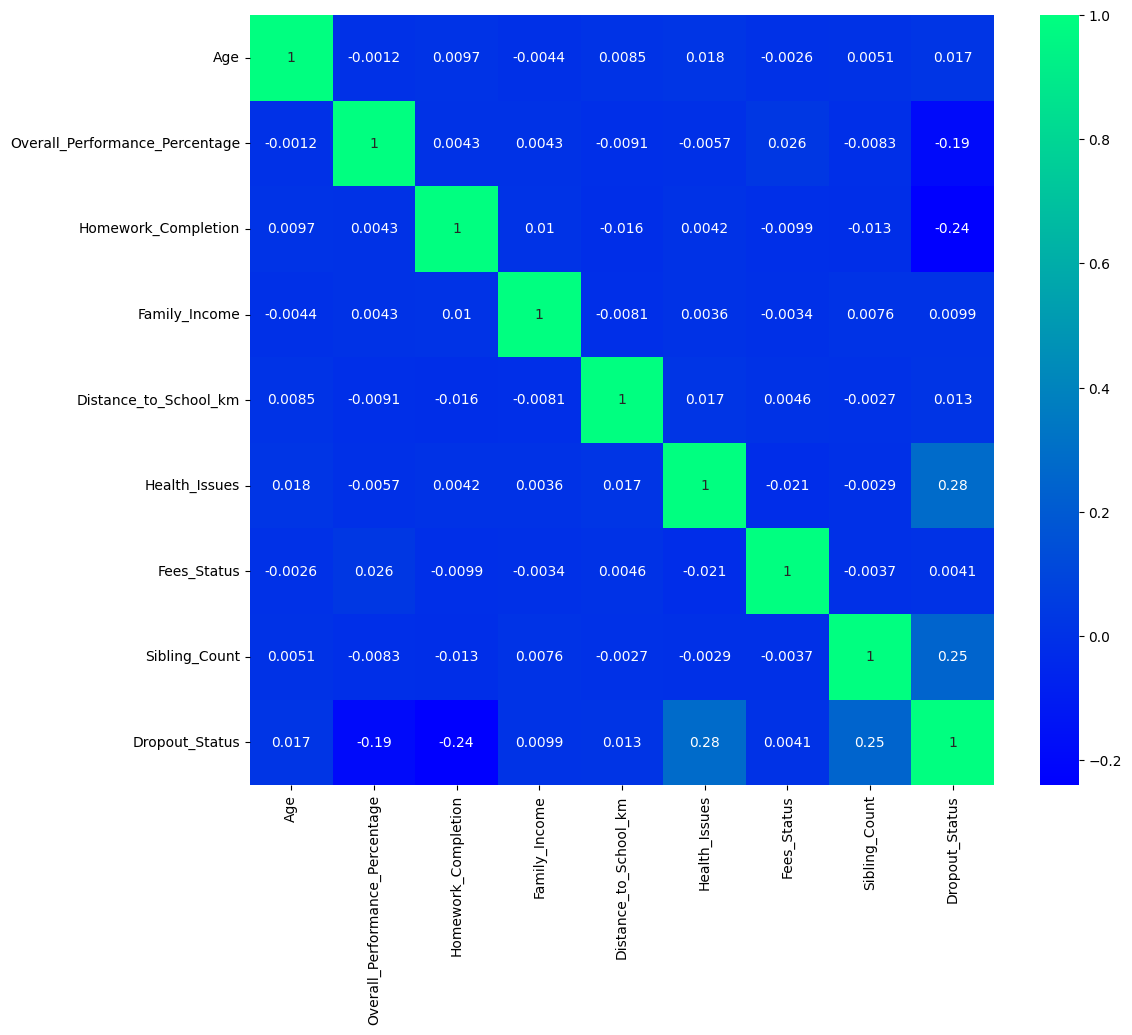

In [15]:
corr=df.drop(columns=['Student_ID','Gender']).corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='winter')
plt.show()

In [16]:
df.isnull().sum()

Student_ID                        0
Age                               0
Gender                            0
Overall_Performance_Percentage    0
Homework_Completion               0
Family_Income                     0
Distance_to_School_km             0
Health_Issues                     0
Fees_Status                       0
Sibling_Count                     0
Dropout_Status                    0
dtype: int64

In [17]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=["Dropout_Status", "Student_ID"])
y = df["Dropout_Status"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=31,stratify=y
)

In [35]:
import numpy as np
import pandas as pd
import optuna
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import (
    RandomForestClassifier,
)
from imblearn.over_sampling import ADASYN
from imblearn.pipeline import Pipeline
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "string"]).columns.tolist()

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])


def objective(trial):
    model_name = trial.suggest_categorical(
        "model",
        [  "xgb",
        ],
    )
    if model_name == "lgbm":
        max_depth = trial.suggest_int("lgbm_max_depth", 3, 8)
        num_leaves = trial.suggest_int("lgbm_num_leaves", 2, min(30, 2**max_depth - 1))
        model = LGBMClassifier(
            n_estimators=trial.suggest_int("lgbm_n_estimators", 100, 300),
            learning_rate=trial.suggest_float("lgbm_lr", 1e-3, 0.3, log=True),
            max_depth=max_depth,
            num_leaves=num_leaves,
            min_child_samples=trial.suggest_int("lgbm_min_child", 10, 100),
            subsample=trial.suggest_float("lgbm_subsample", 0.6, 1.0),
            colsample_bytree=trial.suggest_float("lgbm_colsample", 0.6, 1.0),
            reg_alpha=trial.suggest_float("lgbm_reg_alpha", 0.0, 5.0),
            reg_lambda=trial.suggest_float("lgbm_reg_lambda", 0.0, 5.0),
            is_unbalance=True,
            random_state=31,
            verbosity=-1,
            n_jobs=-1,
        )
    elif model_name == "xgb":
        model = XGBClassifier(
            n_estimators=trial.suggest_int("xgb_n_estimators", 50, 300),
            learning_rate=trial.suggest_float("xgb_lr", 1e-3, 0.5, log=True),
            max_depth=trial.suggest_int("xgb_max_depth", 2, 12),
            min_child_weight=trial.suggest_int("xgb_min_child", 1, 20),
            subsample=trial.suggest_float("xgb_subsample", 0.2, 1.0),
            colsample_bytree=trial.suggest_float("xgb_colsample", 0.2, 1.0),
            gamma=trial.suggest_float("xgb_gamma", 0.0, 10.0),
            reg_alpha=trial.suggest_float("xgb_reg_alpha", 0.0, 10.0),
            reg_lambda=trial.suggest_float("xgb_reg_lambda", 0.0, 10.0),
            random_state=31,
            eval_metric="logloss",
            n_jobs=-1,
        )
    elif model_name == "rf":
        cw = trial.suggest_categorical("rf_class_weight", ["balanced_subsample", "balanced", "none"])
        model = RandomForestClassifier(
            n_estimators=trial.suggest_int("rf_n_estimators", 50, 300),
            max_depth=trial.suggest_int("rf_max_depth", 2, 30),
            min_samples_split=trial.suggest_int("rf_min_split", 2, 20),
            min_samples_leaf=trial.suggest_int("rf_min_leaf", 1, 10),
            max_features=(lambda value: None if value == "none" else value)(
                trial.suggest_categorical("rf_max_features", ["sqrt", "log2", "none"])
            ),
            bootstrap=trial.suggest_categorical("rf_bootstrap", [True, False]),
            class_weight=None if cw == "none" else cw,
            random_state=31,
            n_jobs=-1,
        )
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("adasyn", ADASYN(
        sampling_strategy='auto',
        random_state=42,
        n_neighbors=5
        )),
        ("model", model)
    ])
    from sklearn.model_selection import StratifiedKFold
    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=31,
    )
    from sklearn.model_selection import cross_val_score
    score = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1,
        error_score="raise"
    ).mean()
    return score
study = optuna.create_study(direction="maximize")
study.optimize(
    objective,
    n_trials=100,
    show_progress_bar=True,
)
print("best_accuracy:", study.best_value)
print("best_params:", study.best_params)

[I 2026-07-19 19:05:36,662] A new study created in memory with name: no-name-aef79dd8-3208-4a59-a5cf-f0e29a4c9e7f


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-07-19 19:05:39,487] Trial 0 finished with value: 0.8712857142857142 and parameters: {'model': 'xgb', 'xgb_n_estimators': 172, 'xgb_lr': 0.07507268174205968, 'xgb_max_depth': 4, 'xgb_min_child': 19, 'xgb_subsample': 0.4989398238640095, 'xgb_colsample': 0.4407912693232204, 'xgb_gamma': 1.6203894984495137, 'xgb_reg_alpha': 0.7769061306382119, 'xgb_reg_lambda': 4.016261474872694}. Best is trial 0 with value: 0.8712857142857142.
[I 2026-07-19 19:05:41,235] Trial 1 finished with value: 0.8715714285714287 and parameters: {'model': 'xgb', 'xgb_n_estimators': 282, 'xgb_lr': 0.010616625496357874, 'xgb_max_depth': 8, 'xgb_min_child': 9, 'xgb_subsample': 0.6574664000396125, 'xgb_colsample': 0.38335163813549844, 'xgb_gamma': 6.770404615589013, 'xgb_reg_alpha': 0.14715837951279287, 'xgb_reg_lambda': 3.45531692705738}. Best is trial 1 with value: 0.8715714285714287.
[I 2026-07-19 19:05:42,305] Trial 2 finished with value: 0.8497142857142856 and parameters: {'model': 'xgb', 'xgb_n_estimators':

In [ ]:
import numpy as np
import pandas as pd
from imblearn.over_sampling import ADASYN
from imblearn.pipeline import Pipeline
import optuna
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import (
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
)
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "string"]).columns.tolist()

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])


def objective(trial):
    model_name = trial.suggest_categorical(
        "model",
        ["et", "gb", "ab",
        ],
    )
    if model_name == "et":
        cw = trial.suggest_categorical("et_class_weight", ["balanced_subsample", "balanced", "none"])
        model = ExtraTreesClassifier(
            n_estimators=trial.suggest_int("et_n_estimators", 50, 300),
            max_depth=trial.suggest_int("et_max_depth", 2, 30),
            min_samples_split=trial.suggest_int("et_min_split", 2, 20),
            min_samples_leaf=trial.suggest_int("et_min_leaf", 1, 10),
            max_features=(lambda value: None if value == "none" else value)(
                trial.suggest_categorical("et_max_features", ["sqrt", "log2", "none"])
            ),
            bootstrap=trial.suggest_categorical("et_bootstrap", [True, False]),
            class_weight=None if cw == "none" else cw,
            random_state=31,
        )
    elif model_name == "gb":
        model = GradientBoostingClassifier(
            loss=trial.suggest_categorical("gb_loss", ["log_loss", "exponential"]),
            learning_rate=trial.suggest_float("gb_lr", 1e-2, 0.5, log=True),
            n_estimators=trial.suggest_int("gb_n_estimators", 50, 300),
            subsample=trial.suggest_float("gb_subsample", 0.2, 1.0),
            max_depth=trial.suggest_int("gb_max_depth", 2, 8),
            min_samples_split=trial.suggest_int("gb_min_split", 2, 20),
            min_samples_leaf=trial.suggest_int("gb_min_leaf", 1, 10),
            random_state=31,
        )
    elif model_name == "ab":
        model = AdaBoostClassifier(
            n_estimators=trial.suggest_int("ab_n_estimators", 50, 200),
            learning_rate=trial.suggest_float("ab_lr", 1e-3, 2.0, log=True),
            random_state=31,
        )
    from sklearn.model_selection import cross_val_score
    
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("adasyn", ADASYN(
        sampling_strategy='auto',
        random_state=42,
        n_neighbors=5
        )),
        ("model", model)
    ])
    from sklearn.model_selection import StratifiedKFold
    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=31,
    )
    score = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1,
        error_score="raise"
    ).mean()

    return score
study = optuna.create_study(direction="maximize")
study.optimize(
    objective,
    n_trials=100,
    show_progress_bar=True,
)
print("best_accuracy:", study.best_value)
print("best_params:", study.best_params)

[I 2026-07-19 18:38:32,753] A new study created in memory with name: no-name-80a8f5d6-4a17-4ccb-9bda-89731e945572


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-07-19 18:38:34,536] Trial 0 finished with value: 0.6271425817644414 and parameters: {'model': 'ab', 'ab_n_estimators': 89, 'ab_lr': 0.024561595702830088}. Best is trial 0 with value: 0.6271425817644414.
[I 2026-07-19 18:38:39,892] Trial 1 finished with value: 0.7436573925335732 and parameters: {'model': 'gb', 'gb_loss': 'log_loss', 'gb_lr': 0.2920791691317388, 'gb_n_estimators': 100, 'gb_subsample': 0.6375301714410138, 'gb_max_depth': 6, 'gb_min_split': 3, 'gb_min_leaf': 1}. Best is trial 1 with value: 0.7436573925335732.
[I 2026-07-19 18:39:03,128] Trial 2 finished with value: 0.8409291267750433 and parameters: {'model': 'gb', 'gb_loss': 'exponential', 'gb_lr': 0.014411482098117729, 'gb_n_estimators': 299, 'gb_subsample': 0.8750042559484175, 'gb_max_depth': 6, 'gb_min_split': 7, 'gb_min_leaf': 9}. Best is trial 2 with value: 0.8409291267750433.
[I 2026-07-19 18:39:09,197] Trial 3 finished with value: 0.8530938765019599 and parameters: {'model': 'ab', 'ab_n_estimators': 200, 'a

In [32]:
import numpy as np
import pandas as pd
import optuna
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score
from imblearn.over_sampling import ADASYN
from imblearn.pipeline import Pipeline
from sklearn.linear_model import (
    RidgeClassifier,
    SGDClassifier,
)
from sklearn.neighbors import KNeighborsClassifier
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "string"]).columns.tolist()

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])
def objective(trial):
    model_name = trial.suggest_categorical(
        "model",
        ["ridge", "sgd", "knn",
        ],
    )
    if model_name == "ridge":
        model = RidgeClassifier(
            alpha=trial.suggest_float("ridge_alpha", 1e-3, 30.0, log=True),
            solver=trial.suggest_categorical("ridge_solver", ["auto","lsqr","sag"]),
        )
    elif model_name == "sgd":
        loss = trial.suggest_categorical("sgd_loss", ["hinge", "log_loss", "modified_huber", "perceptron"])
        penalty = trial.suggest_categorical("sgd_penalty", ["l2", "l1", "elasticnet"])
        if loss in ("hinge", "perceptron") and penalty == "elasticnet":
            penalty = "l2"
        model = SGDClassifier(
            alpha=trial.suggest_float("sgd_alpha", 1e-2, 1, log=True),
            max_iter=trial.suggest_int("sgd_max_iter", 500, 3000),
            loss=loss,
            penalty=penalty,
            learning_rate=trial.suggest_categorical("sgd_lr", ["optimal", "invscaling", "constant"]),
            eta0=trial.suggest_float("sgd_eta0", 1e-3, 1.0, log=True),
            random_state=31,
        )
    elif model_name == "knn":
        model = KNeighborsClassifier(
            n_neighbors=trial.suggest_int("knn_k", 1, 30),
            weights=trial.suggest_categorical("knn_weights", ["uniform", "distance"]),
            algorithm=trial.suggest_categorical("knn_alg", ["auto", "ball_tree", "kd_tree", "brute"]),
            p=trial.suggest_int("knn_p", 1, 3),
        )
    from sklearn.model_selection import cross_val_score
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("adasyn", ADASYN(
        sampling_strategy='auto',
        random_state=42,
        n_neighbors=5
        )),
        ("model", model)
    ])
    from sklearn.model_selection import StratifiedKFold
    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=31,
    )
    score = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring="recall",
        n_jobs=-1,
        error_score="raise"
    ).mean()

    return score
study = optuna.create_study(direction="maximize")
study.optimize(
    objective,
    n_trials=100,
    show_progress_bar=True,
)
print("best_accuracy:", study.best_value)
print("best_params:", study.best_params)

[I 2026-07-19 18:45:28,402] A new study created in memory with name: no-name-3964e87f-770b-4ca6-9f99-642f645d09d3


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-07-19 18:45:30,190] Trial 0 finished with value: 0.747717021139883 and parameters: {'model': 'ridge', 'ridge_alpha': 12.473647075416267, 'ridge_solver': 'sag'}. Best is trial 0 with value: 0.747717021139883.
[I 2026-07-19 18:45:33,687] Trial 1 finished with value: 0.8616950459422992 and parameters: {'model': 'knn', 'knn_k': 19, 'knn_weights': 'uniform', 'knn_alg': 'brute', 'knn_p': 2}. Best is trial 1 with value: 0.8616950459422992.
[I 2026-07-19 18:45:34,427] Trial 2 finished with value: 0.7472119771252329 and parameters: {'model': 'sgd', 'sgd_loss': 'modified_huber', 'sgd_penalty': 'l2', 'sgd_alpha': 0.031567003761390794, 'sgd_max_iter': 2164, 'sgd_lr': 'invscaling', 'sgd_eta0': 0.0050386541077187775}. Best is trial 1 with value: 0.8616950459422992.
[I 2026-07-19 18:45:35,035] Trial 3 finished with value: 0.748223350253807 and parameters: {'model': 'ridge', 'ridge_alpha': 0.027068267422808785, 'ridge_solver': 'sag'}. Best is trial 1 with value: 0.8616950459422992.
[I 2026-07-

In [33]:

import numpy as np
import pandas as pd
import optuna
from imblearn.over_sampling import ADASYN
from imblearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import (
    LogisticRegression
)
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "string"]).columns.tolist()

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
],remainder='passthrough')
def objective(trial):
    model_name = trial.suggest_categorical(
        "model",
        [   "logreg","gnb",
        ],
    )
    if model_name == "logreg":
        penalty = trial.suggest_categorical(
            "logreg_penalty",
            ["l1", "l2", "elasticnet"]
        )
        solver = trial.suggest_categorical(
            "logreg_solver",
            ["lbfgs", "liblinear", "saga"]
        )
        if penalty == "l1" and solver == "lbfgs":
            raise optuna.TrialPruned()
        if penalty == "elasticnet" and solver != "saga":
            raise optuna.TrialPruned()
        logreg_kwargs = dict(
            penalty=penalty,
            solver=solver,
            C=trial.suggest_float(
                "logreg_C",
                1e-3,
                60,
                log=True,
            ),
            max_iter=trial.suggest_int(
                "logreg_max_iter",
                1000,
                3000,
            ),
        )
        cw = trial.suggest_categorical(
            "logreg_class_weight",
            ["balanced", "none"],
        )
        if cw != "none":
            logreg_kwargs["class_weight"] = cw

        if penalty == "elasticnet":
            logreg_kwargs["l1_ratio"] = trial.suggest_float(
                "logreg_l1_ratio",
                0,
                1,
            )

        model = LogisticRegression(**logreg_kwargs)
    elif model_name == "gnb":
        model = GaussianNB(var_smoothing=trial.suggest_float("gnb_var_smoothing", 1e-10, 1e-6, log=True))
    from sklearn.model_selection import cross_val_score
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("adasyn", ADASYN(
        sampling_strategy='auto',
        random_state=42,
        n_neighbors=5
        )),
        ("model", model)
    ])
    from sklearn.model_selection import StratifiedKFold
    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=31,
    )
    score = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring="recall",
        n_jobs=-1,
        error_score="raise"
    ).mean()

    return score
study = optuna.create_study(direction="maximize")
study.optimize(
    objective,
    n_trials=100,
    show_progress_bar=True,
)
print("best_accuracy:", study.best_value)
print("best_params:", study.best_params)

[I 2026-07-19 18:50:48,558] A new study created in memory with name: no-name-2320ed42-6432-4835-8560-34ed5518a135


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-07-19 18:50:50,665] Trial 0 finished with value: 0.8465000321274818 and parameters: {'model': 'gnb', 'gnb_var_smoothing': 9.87739933086193e-08}. Best is trial 0 with value: 0.8465000321274818.
[I 2026-07-19 18:50:52,613] Trial 1 finished with value: 0.7446777613570648 and parameters: {'model': 'logreg', 'logreg_penalty': 'elasticnet', 'logreg_solver': 'saga', 'logreg_C': 6.489425477702649, 'logreg_max_iter': 1174, 'logreg_class_weight': 'none', 'logreg_l1_ratio': 0.5940733468901963}. Best is trial 0 with value: 0.8465000321274818.
[I 2026-07-19 18:50:53,407] Trial 2 finished with value: 0.7446777613570648 and parameters: {'model': 'logreg', 'logreg_penalty': 'l2', 'logreg_solver': 'saga', 'logreg_C': 0.024410011486451055, 'logreg_max_iter': 2576, 'logreg_class_weight': 'none'}. Best is trial 0 with value: 0.8465000321274818.
[I 2026-07-19 18:50:54,356] Trial 3 finished with value: 0.7573424147015357 and parameters: {'model': 'logreg', 'logreg_penalty': 'l1', 'logreg_solver': 'l

In [34]:
import numpy as np
import pandas as pd
import optuna
from imblearn.over_sampling import ADASYN
from imblearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "string"]).columns.tolist()
from sklearn.tree import DecisionTreeClassifier
from sklearn import svm
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
],remainder='passthrough')
def objective(trial):
    model_name = trial.suggest_categorical(
        "model",
        [   "svc","dt",
        ],
    )
    if model_name == "svc":
        kernel = trial.suggest_categorical("svc_kernel", ["linear", "rbf", "poly", "sigmoid"])
        svc_kwargs = {
            "C": trial.suggest_float("svc_C", 1e-1, 10.0, log=True),
            "kernel": kernel,
            "shrinking": trial.suggest_categorical("svc_shrinking", [True, False]),
            "random_state": 31,
        }
        if kernel != "linear":
            svc_kwargs["gamma"] = trial.suggest_categorical("svc_gamma", ["scale", "auto"])
        if kernel == ("poly","sigmoid"):
            svc_kwargs["coef0"] = trial.suggest_float("svc_coef0", 0.0, 7.0)
        cw = trial.suggest_categorical("svc_class_weight", ["balanced", "none"])
        if cw != "none":
            svc_kwargs["class_weight"] = cw
        model = svm.SVC(**svc_kwargs)
    elif model_name == "dt":
        mf = trial.suggest_categorical("dt_max_features", ["none", "sqrt", "log2"])
        model = DecisionTreeClassifier(
            criterion=trial.suggest_categorical("dt_criterion", ["gini", "entropy", "log_loss"]),
            splitter=trial.suggest_categorical("dt_splitter", ["best", "random"]),
            max_depth=trial.suggest_int("dt_max_depth", 2, 30),
            min_samples_split=trial.suggest_int("dt_min_split", 2, 20),
            min_samples_leaf=trial.suggest_int("dt_min_leaf", 1, 10),
            max_features=None if mf == "none" else mf,
            random_state=31,
        )
    from sklearn.model_selection import cross_val_score
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("adasyn", ADASYN(
        sampling_strategy='auto',
        random_state=42,
        n_neighbors=3
        )),
        ("model", model)
    ])
    from sklearn.model_selection import StratifiedKFold
    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=31,
    )
    score = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring="recall",
        n_jobs=-1,
        error_score="raise"
    ).mean()

    return score
study = optuna.create_study(direction="maximize")
study.optimize(
    objective,
    n_trials=100,
    show_progress_bar=True,
)
print("best_accuracy:", study.best_value)
print("best_params:", study.best_params)

[I 2026-07-19 18:51:40,583] A new study created in memory with name: no-name-d778bcb2-eed1-4148-a087-31240e4766df


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-07-19 18:51:41,203] Trial 0 finished with value: 0.7401028079419135 and parameters: {'model': 'dt', 'dt_max_features': 'sqrt', 'dt_criterion': 'gini', 'dt_splitter': 'best', 'dt_max_depth': 14, 'dt_min_split': 9, 'dt_min_leaf': 10}. Best is trial 0 with value: 0.7401028079419135.
[I 2026-07-19 18:51:41,583] Trial 1 finished with value: 0.7842125554199063 and parameters: {'model': 'dt', 'dt_max_features': 'none', 'dt_criterion': 'entropy', 'dt_splitter': 'random', 'dt_max_depth': 29, 'dt_min_split': 11, 'dt_min_leaf': 8}. Best is trial 1 with value: 0.7842125554199063.
[I 2026-07-19 18:51:41,938] Trial 2 finished with value: 0.7968566471759944 and parameters: {'model': 'dt', 'dt_max_features': 'none', 'dt_criterion': 'entropy', 'dt_splitter': 'random', 'dt_max_depth': 21, 'dt_min_split': 8, 'dt_min_leaf': 9}. Best is trial 2 with value: 0.7968566471759944.
[I 2026-07-19 18:51:42,307] Trial 3 finished with value: 0.6894557604574953 and parameters: {'model': 'dt', 'dt_max_features

In [ ]:


# xgb
#               precision    recall  f1-score   support

#            0       0.95      0.88      0.91      2154
#            1       0.74      0.88      0.80       846

#     accuracy                           0.88      3000
#    macro avg       0.84      0.88      0.86      3000
# weighted avg       0.89      0.88      0.88      3000

# [[1891  263]
#  [ 102  744]]


In [39]:
from xgboost import XGBClassifier
xgb = XGBClassifier(
    n_estimators=183,
    learning_rate=0.010124520201234307,
    max_depth=6,
    min_child_weight=10,
    subsample=0.8027843959008066,
    colsample_bytree=0.4794704095310949,
    gamma=7.634586313518941,
    reg_alpha=2.0083834690944613,
    reg_lambda=3.0727277849515904,
    eval_metric="logloss",
    random_state=31,
    n_jobs=-1,
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "string"]).columns.tolist()
numeric_transformer = Pipeline([
    ("scaler", StandardScaler()),
])
categorical_transformer = Pipeline([
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])
pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("adasyn", ADASYN(
        sampling_strategy='auto',
        random_state=42,
        n_neighbors=5
        )),
        ("model", xgb)
    ])
pipe.fit(X_train,y_train)
preds=pipe.predict(X_test)
print(classification_report(y_test, preds))
print(confusion_matrix(y_test, preds))

              precision    recall  f1-score   support

           0       0.95      0.88      0.91      2154
           1       0.74      0.88      0.80       846

    accuracy                           0.88      3000
   macro avg       0.84      0.88      0.86      3000
weighted avg       0.89      0.88      0.88      3000

[[1891  263]
 [ 102  744]]


In [40]:
import pickle

with open("model.pkl", "wb") as f:
    pickle.dump(pipe, f)